# Proyek Analisis Data: [E-Commerce Public Dataset ]
- **Nama:** Muh. Fadhil Syam
- **Email:** Fasyamuhammad41@gmail.com
- **ID Dicoding:** faxyza

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi rating pelanggan berdasarkan waktu pengiriman dan kategori produk?

- Bagaimana perkembangan revenue bulanan selama periode 2016–2018?

- Bagaimana segmentasi customer berdasarkan nilai belanja?

- Seberapa besar perbedaan rata-rata nilai transaksi dan frekuensi pembelian berdasarkan metode pembayaran yang digunakan?

- Seberapa besar perbedaan tingkat kepuasan pelanggan dan repeat order antara pengiriman tepat waktu dan terlambat?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### 1. Customer_df (customers_dataset.csv)

In [ ]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


**Insight:**
- Dataset berada pada level pelanggan (customer) dengan identifikasi unik menggunakan customer_unique_id.
- Variabel utama bersifat geografis dan relevan untuk analisis persebaran pelanggan.


#### 2. order_payment (order_payment_dataset.csv)

In [ ]:
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_payments_df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


**Insight:**
- Dataset berada pada level pembayaran (order payment), di mana satu order dapat memiliki lebih dari satu tahapan pembayaran.
- Metode pembayaran didominasi oleh credit_card, dengan variasi jumlah cicilan (payment_installments).
- Dataset mendukung analisis perilaku pembayaran pelanggan dan preferensi metode pembayaran.


#### 3. order_items_df (order_items_dataset.csv)

In [ ]:
order_items_df =  pd.read_csv("order_items_dataset.csv")
order_items_df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


**Insight:**
- Dataset berada pada level order item sehingga satu order dapat muncul beberapa kali.
- Variabel numerik utama adalah price dan freight_value yang relevan untuk analisis revenue.
- Tersedia informasi waktu pengiriman yang memungkinkan analisis SLA pengiriman.
- Dataset mencakup banyak seller dan produk unik.


#### 4. order_review_df (order_reviews_dataset.csv)

In [ ]:
order_reviews_df =  pd.read_csv("order_reviews_dataset.csv")
order_reviews_df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


**Insight:**
- Data berada pada level order dan terhubung langsung dengan tabel order melalui order_id.
- Review_score dapat digunakan sebagai indikator kepuasan pelanggan.
- Tingginya missing value pada kolom komentar menunjukkan banyak ulasan berupa skor saja.
- Data teks memungkinkan eksplorasi sentimen pelanggan.
- Informasi timestamp mendukung analisis kecepatan respon terhadap ulasan.


#### 5. orders_df (order_dataset.csv)

In [ ]:
orders_df =  pd.read_csv("orders_dataset.csv")
orders_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


**Insight:**
- Dataset berada pada level order dengan order_id unik per baris.  
- Tersedia banyak timestamp yang memungkinkan pembuatan fitur durasi (approval time, shipping time, delivery delay).  
- order_status dapat digunakan sebagai **label kategorikal** untuk analisis performa penyelesaian pesanan.  
- Perbandingan tanggal aktual vs estimasi mendukung analisis SLA pengiriman.  
- Fitur waktu pembelian dapat diturunkan menjadi variabel musiman dan tren permintaan.  


In [ ]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


**Insight:**
- Dataset berada pada level produk, dengan product_id unik sebagai identifier utama.  
- Tersedia fitur teks seperti product_name_length dan product_description_length yang dapat digunakan sebagai proxy kompleksitas informasi produk.  
- Variabel`product_photos_qty berpotensi dianalisis terhadap performa penjualan atau ketertarikan pelanggan.  
- Fitur fisik produk (product_weight_g, product_length_cm, product_height_cm, product_width_cm) mendukung analisis logistik dan estimasi biaya pengiriman.  
- product_category_name memungkinkan segmentasi dan analisis performa berbasis kategori produk.  


#### 6. Product_df (products_dataset.csv)

In [ ]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


**Insight:**
- Dataset berada pada level produk, dengan product_id unik sebagai identifier utama.  
- Tersedia fitur teks seperti product_name_length dan product_description_length yang dapat digunakan sebagai proxy kompleksitas informasi produk.  
- Variabel`product_photos_qty berpotensi dianalisis terhadap performa penjualan atau ketertarikan pelanggan.  
- Fitur fisik produk (product_weight_g, product_length_cm, product_height_cm, product_width_cm) mendukung analisis logistik dan estimasi biaya pengiriman.  
- product_category_name memungkinkan segmentasi dan analisis performa berbasis kategori produk.  


### Assessing Data

#### 1. Menilai data  customers_df (customer_dataset.csv)

In [ ]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Insight:**
- Dataset menampilkan jumlah data dan type data
- jumlah data sesuai tidak ada yang hilang
- tapi ada kejanggalan ditipe data kolom (customer_zip_code_prefix), karena ini merupakan kode pos. dan bukan nilai numerik untuk perhitungan

In [ ]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**

Tidak ada data yang yang keliru karena semestinya kolom (customer_zip_code_prefix) merupakan kode pos yang mestinya bukan bertipe data integer

#### 2. Menilai data order_payment_df (order_payments_dataset.csv)

In [ ]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight & Kejanggalan:**
- Dataset berada pada level pembayaran, sehingga satu order_id dapat muncul lebih dari satu kali dan **perlu agregasi per order** untuk menghindari double counting saat analisis revenue.
- Seluruh kolom non-null, namun validasi logis tetap diperlukan (misalnya nilai payment_installments).
- payment_installments hanya relevan untuk metode tertentu (seperti credit_card) dan **harus difilter atau disesuaikan** saat analisis dan visualisasi.

In [ ]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- Mayoritas transaksi memiliki payment_sequential = 1, menunjukkan sebagian besar order dibayar dalam satu tahap, meskipun terdapat hingga 29 tahap pembayaran pada kasus tertentu.
- Nilai median payment_installments adalah 1, menandakan sebagian besar transaksi tidak menggunakan cicilan, namun terdapat outlier hingga 24 kali cicilan.
- Distribusi payment_value bersifat right-skewed, dengan median sekitar 100 dan nilai maksimum sangat tinggi (13.664), sehingga berpotensi memengaruhi rata-rata.
- Terdapat nilai minimum 0 pada payment_installments dan payment_value yang perlu diverifikasi karena berpotensi tidak valid untuk analisis revenue.


#### 3. Menilai order_items_df (order_items_dataset.csv)

In [ ]:
order_items_df.info(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**
- Dataset berada pada level order item, sehingga satu order dapat memiliki beberapa baris data.
- Variabel utama untuk analisis nilai transaksi adalah price dan freight_value.
- shipping_limit_date perlu dikonversi ke datetime untuk analisis waktu.
- Data perlu diagregasi ke level order agar tidak terjadi double counting pada analisis selanjutnya.


In [ ]:
print("jumlah duplikasi", order_items_df.duplicated().sum())

jumlah duplikasi 0


In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Mayoritas order hanya memiliki satu item (order_item_id = 1).
- Distribusi price dan freight_value tidak normal dan memiliki outlier tinggi.
- Nilai freight_value = 0 perlu diverifikasi sebelum analisis lanjutan.


#### 4. Menilai order_reviews_df (order_reviews_dataset,csv)

In [ ]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:**
- Dataset berada pada level review per order, satu order dapat memiliki satu review.
- Variabel utama untuk analisis kepuasan adalah review_score.
- Kolom teks review tidak sepenuhnya terisi dan perlu penanganan missing value.
- Kolom waktu (review_creation_date, review_answer_timestamp) perlu dikonversi ke datetime untuk analisis temporal.


In [ ]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight**

- Kolom review_comment_title memiliki kehilangan data yang sangat tinggi (87.656 baris).
- Kolom review_comment_message juga memiliki banyak data hilang (58.247 baris).

In [ ]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- Mayoritas review_score bernilai 5.
- Rata-rata rating tinggi (≈4,1) menandakan kepuasan pelanggan sangat baik.
- Distribusi skor tidak merata dan condong ke nilai maksimum.


#### 5. Menilai order_datasets (order_dataset.csv)

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**
- Dataset berada pada level order dengan total 99.441 data.
- Beberapa kolom waktu memiliki missing value, terutama order_delivered_carrier_date dan order_delivered_customer_date.
- Seluruh kolom bertipe object, sehingga kolom tanggal perlu dikonversi ke datetime untuk analisis waktu.



In [ ]:
print("Jumlah duplicate: ", orders_df.duplicated().sum())

Jumlah duplicate:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Mayoritas order berstatus delivered.
- Terdapat beberapa missing value pada kolom waktu pengiriman.
- order_estimated_delivery_date memiliki banyak nilai yang sama dan perlu diperhatikan saat analisis keterlambatan.


#### 6. Menilai Data Product_df (product_dataset.csv)

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Dataset berisi data produk dengan beberapa kolom memiliki missing value.
- Variabel numerik berkaitan dengan ukuran dan berat produk.


In [ ]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- Sebagian besar produk memiliki 1 foto.
- Berat dan dimensi produk memiliki outlier yang tinggi.
- Terdapat nilai berat produk 0 yang perlu dicek kevalidannya.


### Cleaning Data

#### 1. Membersihkan data Customer_df

In [ ]:
customers_df["customer_zip_code_prefix"] = (
    customers_df["customer_zip_code_prefix"].astype(str)
)

customers_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


**Insight:**
Untuk data customer_df permasalahannya hanyalah terletak pada jenis kolom customer_zip_code_prefix yang bertipe float diubah menjadi object

In [ ]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
customers_df[customers_df.isnull().any(axis=1)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [ ]:
customers_df.dropna(axis=0, inplace=True)

customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


#### 2. Memberishkan data order_payment

In [ ]:
order_payments_df.dropna(axis=0, inplace=True)

order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_payments_df["payment_installments"] = (
    order_payments_df["payment_installments"].astype(int)
)


order_payments_df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_payments_df[order_payments_df.payment_installments.isna()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [ ]:
order_payments_df[order_payments_df.payment_installments == order_payments_df.payment_installments.min()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [ ]:
order_payments_df[order_payments_df.payment_value == order_payments_df.payment_value.min()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [ ]:
order_payments_df[order_payments_df["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [ ]:
order_payments_df = order_payments_df[
    order_payments_df["payment_type"] != "not_defined"
]

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Data dengan payment_type = not_defined dihapus karena jumlahnya sangat sedikit dan tidak merepresentasikan metode pembayaran yang valid.
- Metode yang digunakan adalah drop untuk menghindari gangguan pada analisis pembayaran.
- Nilai minimum pada payment_installments dan payment_value tidak dihapus karena masih masuk akal dalam konteks proses transaksi (misalnya voucher atau promo).
- milihat dan menghapus nilai missing value dari data order_payment. karena hanya 1 data baris yang bernilai missing value jadi mentode yang digunakan untuk menanganinya adalah dropna (menhapusnya)
- merubah tipe data payment_installments yang awalnya float menjadi int


#### 3. Membersihkan data Order_items df

In [ ]:
order_items_df["shipping_limit_date"]=pd.to_datetime(
    order_items_df["shipping_limit_date"])

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
order_items_df[order_items_df.isnull().any(axis=1)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [ ]:
order_items_df.dropna(axis=0, inplace=True)

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
order_items_df.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


**Insight :**

- mengganti tipe data shipping_limit_date yang awalnya object menjadi datetime
- menghapus missing value

#### 4. Membersihkan data order_reviews_df

In [ ]:
order_reviews_df[order_reviews_df.isnull().any(axis=1)]


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [ ]:
date_time = ["review_creation_date", "review_answer_timestamp"]

for col in date_time:
  order_reviews_df[col] = pd.to_datetime(order_reviews_df[col])

order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [ ]:
order_reviews_df[order_reviews_df.isnull().any(axis=1)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


**Insight:**

- data yang hilang pada kolom review_comment_title dan kolom review_comment_title tidak ditangani karena untuk analisis nantinya hanya menggunakan rating sehingga comment akan diabaikan
- mengubah tipe data yang berkaitan dengan tanggal dan waktu menjadi tipe data datetime, yang awalnya adalah object

#### 5. Membersihkan data order_df

In [ ]:
date_time2 = ["order_purchase_timestamp", "order_approved_at",
              "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_time2:
  orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
orders_df[orders_df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [ ]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight :**

- Merubah data yang awalnya object menjadi detetime
- karena didominasi data datetime sehingga untuk missing value diabaikan karena untuk kolom atau fitur yang digunakan hanyalah order_purchase_timestamp

#### 6. Membersihkan data Product_df

In [ ]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
products_df[products_df.isnull().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [ ]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Exploratory Data Analysis (EDA)

### Explore data orders_df



In [ ]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [ ]:
orders_df["order_id"].nunique(), orders_df.shape[0]

(99441, 99441)

In [ ]:
orders_df['order_status'].value_counts()
orders_df['order_status'].value_counts(normalize=True) * 100

,proportion
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


**Insight**

- 97% pesanan berhasil dikirim, menunjukkan sistem pemesanan dan pengiriman berjalan sangat efektif.
- Pesanan bermasalah kurang dari 1,3%, menandakan tingkat pembatalan dan kegagalan sangat rendah.
- Pesanan yang masih dalam proses jumlahnya sangat kecil, sehingga tidak terjadi penumpukan order.
- Alur pemesanan tergolong matang dan stabil, dengan hampir tidak ada pesanan tertahan di tahap awal.

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

In [ ]:
orders_df['order_purchase_timestamp'].min(), orders_df['order_purchase_timestamp'].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

**Insight**

- Pesanan pertama dalam dataset tercatat pada 4 September 2016 pukul 21:15:19.
- Pesanan terakhir dalam dataset tercatat pada 17 Oktober 2018 pukul 17:30:18.

In [ ]:
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

orders_df['year'].value_counts().sort_index()
orders_df.groupby('month')['order_id'].count()

,order_id
month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


In [ ]:
orders_per_year = (
    orders_df['year']
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_per_year.columns = ['year', 'total_orders']
orders_per_year

,year,total_orders
0,2016,329
1,2017,45101
2,2018,54011


**Insight**

- Tahun 2016 tercatat 329 pesanan.
- Tahun 2017 tercatat 45.101 pesanan.
- Tahun 2018 tercatat 54.011 pesanan.
- Data pesanan mencakup tiga tahun, yaitu 2016, 2017, dan 2018.

In [ ]:
orders_per_month = (
    orders_df
    .groupby('month')['order_id']
    .count()
    .reset_index()
)

orders_per_month.columns = ['month', 'total_orders']
orders_per_month

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


**Insight**

- Data pesanan bulanan tercatat dari September 2016 hingga Oktober 2018.
- Jumlah pesanan sangat kecil pada September 2016, Oktober 2016, dan Desember 2016.
- Sepanjang tahun 2017, jumlah pesanan bulanan berada pada ratusan hingga ribuan, dengan nilai tertinggi pada November 2017 sebanyak 7.544 pesanan.
- Pada tahun 2018, jumlah pesanan bulanan relatif tinggi dari Januari hingga Agustus, dengan kisaran sekitar 6.000–7.200 pesanan.
- Terjadi penurunan tajam jumlah pesanan pada September 2018 dan Oktober 2018 dengan masing-masing 16 dan 4 pesanan.

In [ ]:
orders_df['delivery_duration'] = (
    orders_df['order_delivered_customer_date'] -
    orders_df['order_purchase_timestamp']
).dt.days

orders_df['delivery_duration'].describe()

,delivery_duration
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**Insight**

- Jumlah data durasi pengiriman tercatat sebanyak 96.476 pesanan.
- Rata-rata durasi pengiriman adalah 12 hari.
- Nilai tengah (median) durasi pengiriman adalah 10 hari.
- Sebanyak 25% pesanan memiliki durasi pengiriman 6 hari atau kurang.
- Sebanyak 75% pesanan memiliki durasi pengiriman 15 hari atau kurang.
- Durasi pengiriman minimum adalah 0 hari.
- Durasi pengiriman maksimum adalah 209 hari.
- Standar deviasi durasi pengiriman sebesar 9,55 hari.

In [ ]:
orders_df['delivery_delay'] = (
    orders_df['order_delivered_customer_date'] -
    orders_df['order_estimated_delivery_date']
).dt.days

orders_df['delivery_delay'].describe()

,delivery_delay
count,96476.000000
mean,-11.876881
std,10.183854
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


**Insight**

- Jumlah data selisih pengiriman tercatat sebanyak 96.476 pesanan.
- Rata-rata selisih pengiriman adalah −11,88 hari.
- Nilai tengah (median) selisih pengiriman adalah −12 hari.
- Sebanyak 25% pesanan memiliki selisih pengiriman −17 hari atau lebih kecil.
- Sebanyak 75% pesanan memiliki selisih pengiriman −7 hari atau lebih kecil.
- Selisih pengiriman minimum tercatat −147 hari.
- Selisih pengiriman maksimum tercatat 188 hari.
- Standar deviasi selisih pengiriman sebesar 10,18 hari.

In [ ]:
orders_df['delivery_status'] = orders_df['delivery_delay'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

orders_df['delivery_status'].value_counts()
orders_df['delivery_status'].value_counts(normalize=True) * 100

,proportion
delivery_status,
On Time,93.428264
Late,6.571736


**Insight**

- Pesanan dengan status pengiriman tepat waktu tercatat sebesar 93,43%.
- Pesanan dengan status pengiriman terlambat tercatat sebesar 6,57%.

### Explore data customers_df

In [ ]:
customers_df['customer_unique_id'].nunique()

96096

In [ ]:
orders_basic = pd.read_csv("orders_dataset.csv", usecols=['order_id', 'customer_id'])

customer_orders = (
    orders_basic
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

customer_orders.describe()

,order_id
count,96096.000000
mean,1.034809
std,0.214384
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


**Insight**

- Jumlah pelanggan tercatat sebanyak 96.096.  
- Rata-rata jumlah order per pelanggan adalah 1,03.  
- Mayoritas pelanggan melakukan 1 order, dengan nilai median 1.  
- Jumlah order maksimum per pelanggan adalah 17.  
- Standar deviasi jumlah order per pelanggan sebesar 0,21.

In [ ]:
repeat_flag = customer_orders.apply(lambda x: 'Repeat' if x > 1 else 'Single')

repeat_flag.value_counts()
repeat_flag.value_counts(normalize=True) * 100

,proportion
order_id,
Single,96.881244
Repeat,3.118756


**Insight**

- Mayoritas pelanggan melakukan 1 order saja (Single) sebesar 96,88%.  
- Pelanggan yang melakukan lebih dari 1 order (Repeat) hanya 3,12%.

In [ ]:
customer_orders.value_counts().sort_index()

,count
order_id,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


**Insight**

- Sebagian besar pelanggan melakukan 1 order, yaitu 93.099 pelanggan.  
- Pelanggan dengan 2 order tercatat 2.745, dan jumlah pelanggan menurun seiring bertambahnya jumlah order.  
- Hanya 1 pelanggan yang melakukan 9 order dan 1 pelanggan yang melakukan 17 order.  
- Mayoritas pelanggan termasuk kategori pembeli tunggal (1 order).

In [ ]:
def order_segment(x):
    if x == 1:
        return 'Low'
    elif x <= 3:
        return 'Medium'
    else:
        return 'High'

order_segment_series = customer_orders.apply(order_segment)
order_segment_series.value_counts()

,count
order_id,
Low,93099
Medium,2948
High,49


**Insight**

- Mayoritas pelanggan termasuk segmen Low dengan 93.099 pelanggan (1 order).  
- Segmen Medium tercatat 2.948 pelanggan (2–3 order).  
- Segmen High hanya 49 pelanggan (lebih dari 3 order).  
- Sebagian besar pelanggan melakukan sedikit order.  

In [ ]:
order_payments_df = pd.read_csv("order_payments_dataset.csv")

customer_spending = (
    orders_basic
    .merge(order_payments_df[['order_id', 'payment_value']], on='order_id')
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
    .groupby('customer_unique_id')['payment_value']
    .sum()
)

customer_spending.describe()

,payment_value
count,96095.000000
mean,166.594226
std,231.428912
min,0.000000
25%,63.120000
50%,108.000000
75%,183.530000
max,13664.080000


**Insight**

- Jumlah pelanggan tercatat sebanyak 96.095.  
- Rata-rata total pengeluaran per pelanggan adalah 166,59.  
- Nilai tengah (median) pengeluaran per pelanggan adalah 108,00.  
- Sebagian besar pelanggan berpengeluaran antara 63,12 (25%) hingga 183,53 (75%).  
- Pengeluaran minimum 0 dan maksimum 13.664,08.

In [ ]:
spending_segment = pd.qcut(
    customer_spending,
    q=3,
    labels=['Low', 'Medium', 'High']
)

spending_segment.value_counts()

,count
payment_value,
Low,32034
High,32032
Medium,32029


**Insight**

- Pelanggan terbagi hampir merata dalam tiga segmen pengeluaran.  
- Segmen Low berjumlah 32.034 pelanggan.  
- Segmen Medium berjumlah 32.029 pelanggan.  
- Segmen High berjumlah 32.032 pelanggan.  

In [ ]:
customer_profile = pd.DataFrame({
    'total_orders': customer_orders,
    'total_spending': customer_spending
})

customer_profile.describe()

,total_orders,total_spending
count,96096.000000,96095.000000
mean,1.034809,166.594226
std,0.214384,231.428912
min,1.000000,0.000000
25%,1.000000,63.120000
50%,1.000000,108.000000
75%,1.000000,183.530000
max,17.000000,13664.080000


**Insight**

- Jumlah pelanggan tercatat sebanyak 96.096.  
- Rata-rata pelanggan melakukan 1,03 order dengan total pengeluaran rata-rata 166,59.  
- Mayoritas pelanggan melakukan 1 order (median 1) dengan pengeluaran median 108,00.  
- Pengeluaran per pelanggan berkisar antara 0 hingga 13.664,08, sedangkan jumlah order berkisar 1 hingga 17.

In [ ]:
top_zip = (
    customers_df
    .groupby("customer_zip_code_prefix")
    .agg(
        total_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_customers", ascending=False)
    .head(10)
)

top_zip

,total_customers
customer_zip_code_prefix,
22790,136
22793,119
24220,114
24230,113
22775,107
29101,100
13212,92
35162,91
22631,87


**Insight**

- Sepuluh kode pos dengan jumlah pelanggan terbanyak berkisar antara 86 hingga 136 pelanggan.  
- Kode pos dengan pelanggan terbanyak adalah 22790 dengan 136 pelanggan.  
- Kode pos lain yang menempati peringkat teratas antara lain 22793, 24220, 24230, dan 22775.

### Explore data order_paymets_df

In [ ]:
order_payments_df.groupby("order_id").size().describe()

,0
count,99440.000000
mean,1.044710
std,0.381166
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,29.000000


**Insight**

- Jumlah order yang memiliki data pembayaran tercatat sebanyak 99.437.
- Rata-rata jumlah pembayaran per order adalah 1,04.
- Nilai tengah (median) jumlah pembayaran per order adalah 1.
- Sebanyak 75% order memiliki 1 pembayaran.
- Jumlah pembayaran minimum per order adalah 1.
- Jumlah pembayaran maksimum per order adalah 29.
- Standar deviasi jumlah pembayaran per order sebesar 0,38.

In [ ]:
order_payments_df.groupby("order_id").agg(
    total_payment_rows=("payment_value", "count"),
    total_payment_value=("payment_value", "sum")
).describe()

,total_payment_rows,total_payment_value
count,99440.000000,99440.000000
mean,1.044710,160.990267
std,0.381166,221.951257
min,1.000000,0.000000
25%,1.000000,62.010000
50%,1.000000,105.290000
75%,1.000000,176.970000
max,29.000000,13664.080000


**Insight**

- Terdapat 99.437 order dengan data pembayaran.
- Sebagian besar order memiliki 1 kali pembayaran.
- Nilai pembayaran per order berkisar dari 9,59 hingga 13.664,08.

In [ ]:
order_payments_df.groupby("payment_type").agg({
    "order_id": "nunique",
    "payment_value": ["mean", "sum"]
})

order_id payment_value             
              nunique          mean          sum
payment_type                                    
boleto          19784    145.034435   2869361.27
credit_card     76505    163.319021  12542084.19
debit_card       1528    142.570170    217989.79
not_defined         3      0.000000         0.00
voucher          3866     65.703354    379436.87

**Insight**

- Metode pembayaran yang digunakan pada order terbanyak adalah credit_card dengan 76.505 order.
- Metode boleto digunakan pada 19.784 order, sedangkan voucher dan debit_card digunakan pada jumlah order yang jauh lebih kecil.
- Total nilai pembayaran terbesar berasal dari credit_card sebesar 12.542.084,19.
- Rata-rata nilai pembayaran tertinggi terdapat pada credit_card, sedangkan terendah pada voucher.

In [ ]:
order_revenue = (
    order_payments_df
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue = (
    orders_df
    .merge(order_revenue, on="order_id")
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue_summary = (
    monthly_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_revenue_summary

,total_revenue,total_orders
order_month,,
2016-09,252.24,3
2016-10,59090.48,324
2016-12,19.62,1
2017-01,138488.04,800
2017-02,291908.01,1780
2017-03,449863.60,2682
2017-04,417788.03,2404
2017-05,592918.82,3700
2017-06,511276.38,3245


**Insight**

- Pendapatan bulanan meningkat signifikan dari 2016 hingga 2018.
- Bulan dengan pendapatan tertinggi terjadi pada Januari 2018 sebesar 1.115.004,18.
- Sebagian besar bulan memiliki total order ribuan, kecuali bulan awal dan akhir dataset (2016-09, 2016-12, 2018-09, 2018-10) dengan order sangat sedikit.
- Tren pendapatan bulanan sejalan dengan jumlah order.

In [ ]:
payment_repeat = (
    order_payments_df
    .merge(orders_df, on="order_id")
    .merge(customers_df, on="customer_id")
    .groupby("payment_type")
    .agg(
        avg_orders_per_customer=("customer_unique_id", "count")
    )
)

payment_repeat

,avg_orders_per_customer
payment_type,
boleto,19784
credit_card,76795
debit_card,1529
not_defined,3
voucher,5775


**Insight**

- Metode pembayaran credit_card digunakan pada jumlah order terbanyak, yaitu 76.795 order.
- Metode boleto digunakan pada 19.784 order.
- Metode voucher digunakan pada 5.775 order, sedangkan debit_card pada 1.529 order.
- Sebagian besar pelanggan melakukan order menggunakan credit_card.

In [ ]:
payment_review = (
    order_payments_df
    .merge(order_reviews_df, on="order_id")
    .groupby("payment_type")
    .agg(
        avg_rating=("review_score", "mean"),
        avg_payment_value=("payment_value", "mean")
    )
)

payment_review

,avg_rating,avg_payment_value
payment_type,,
boleto,4.086631,144.468993
credit_card,4.087637,162.972784
debit_card,4.168084,142.682786
not_defined,1.666667,0.000000
voucher,4.003804,64.807358


**Insight**

- Rata-rata review score tertinggi terdapat pada debit_card (4,17) dan terendah pada voucher (4,00).  
- Rata-rata nilai pembayaran tertinggi terdapat pada credit_card (162,97) dan terendah pada voucher (64,81).  
- Metode pembayaran lain (boleto dan debit_card) memiliki rata-rata review score sekitar 4,08.

In [ ]:
payment_impact = (
    order_payments_df
    .groupby("payment_type")
    .agg(
        avg_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median"),
        total_revenue=("payment_value", "sum"),
        total_transactions=("order_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
)

payment_impact

,avg_payment_value,median_payment_value,total_revenue,total_transactions
payment_type,,,,
credit_card,163.319021,106.87,12542084.19,76795
boleto,145.034435,93.89,2869361.27,19784
voucher,65.703354,39.28,379436.87,5775
debit_card,142.570170,89.30,217989.79,1529
not_defined,0.000000,0.00,0.00,3


**Insight**

- Total pendapatan terbesar berasal dari credit_card sebesar 12.542.084,19, diikuti oleh boleto, voucher, dan debit_card.  
- Rata-rata nilai pembayaran tertinggi terdapat pada credit_card (163,32) dan terendah pada voucher (65,70).  
- Median pembayaran juga tertinggi pada credit_card (106,87) dan terendah pada voucher (39,28).  
- Jumlah transaksi terbanyak menggunakan credit_card (76.795), sedangkan debit_card paling sedikit (1.529).

### Explore data order_reviews_df

In [ ]:
order_reviews_df["order_id"].value_counts().head()

,count
order_id,
03c939fd7fd3b38f8485a0f95798f1f6,3
8e17072ec97ce29f0e1f111e598b0c85,3
c88b1d1b157a9999ce368f218a407141,3
df56136b8031ecd28e200bb18e6ddb2e,3
843be4a0dcdb9716de7652d53af4acab,2


In [ ]:
order_reviews_df.groupby("order_id").agg({
    "review_score": ["count", "mean", "min", "max"]
})

review_score             
                                        count mean min max
order_id                                                  
00010242fe8c5a6d1ba2dd792cb16214            1  5.0   5   5
00018f77f2f0320c557190d7a144bdd3            1  4.0   4   4
000229ec398224ef6ca0657da4fc703e            1  5.0   5   5
00024acbcdf0a6daa1e931b038114c75            1  4.0   4   4
00042b26cf59d7ce69dfabb4e55b4fd9            1  5.0   5   5
...                                       ...  ...  ..  ..
fffc94f6ce00a00581880bf54a75a037            1  5.0   5   5
fffcd46ef2263f404302a634eb57f7eb            1  5.0   5   5
fffce4705a9662cd70adb13d4a31832d            1  5.0   5   5
fffe18544ffabc95dfada21779c9644f            1  5.0   5   5
fffe41c64501cc87c801fd61db3f6244            1  5.0   5   5

[98673 rows x 4 columns]

**Insight – Order Reviews**
- Sebagian kecil order memiliki lebih dari satu review, namun mayoritas order hanya memiliki satu review
- Review score per order bersifat konsisten (nilai min = max)
- Tidak ditemukan variasi rating dalam satu order
- Data review bersih dan valid untuk analisis kepuasan pelanggan per order

In [ ]:
order_reviews_df['review_score'].value_counts().sort_index()
order_reviews_df['review_score'].value_counts(normalize=True).sort_index() * 100

,proportion
review_score,
1,11.513344
2,3.175643
3,8.242965
4,19.291704
5,57.776344


**Insight**

- Review score 1 tercatat sebesar 11,51%.
- Review score 2 tercatat sebesar 3,18%.
- Review score 3 tercatat sebesar 8,24%.
- Review score 4 tercatat sebesar 19,29%.
- Review score 5 tercatat sebesar 57,78%.

In [ ]:
order_reviews_df['review_score'].describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight**

- Jumlah data review tercatat sebanyak 99.224.
- Nilai rata-rata review score adalah 4,09.
- Nilai tengah (median) review score adalah 5.
- Sebanyak 25% data memiliki review score 4 atau lebih rendah.
- Sebanyak 75% data memiliki review score 5 atau lebih rendah.
- Review score minimum adalah 1.
- Review score maksimum adalah 5.
- Standar deviasi review score sebesar 1,35.

In [ ]:
order_reviews_df['review_creation_date'] = pd.to_datetime(
    order_reviews_df['review_creation_date']
)

order_reviews_df['review_creation_date'].min(), order_reviews_df['review_creation_date'].max()

(Timestamp('2016-10-02 00:00:00'), Timestamp('2018-08-31 00:00:00'))

**Insight**

- Tanggal review paling awal tercatat pada 2 Oktober 2016.
- Tanggal review paling akhir tercatat pada 31 Agustus 2018.
- Data review mencakup periode dari tahun 2016 hingga 2018.

In [ ]:
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(
    order_reviews_df['review_answer_timestamp']
)

order_reviews_df['review_answer_timestamp'].isnull().sum()

np.int64(0)

**Insight**

- Tidak terdapat nilai kosong pada kolom review_answer_timestamp.
- Seluruh data review memiliki waktu jawaban yang tercatat.

### Explore data order_items_df

In [ ]:
order_items_df.groupby('order_id').size().describe()

,0
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


**Insight**

- Jumlah order tercatat sebanyak 98.666.  
- Rata-rata item per order adalah 1,14.  
- Mayoritas order hanya berisi 1 item (median 1).  
- Item per order berkisar antara 1 hingga 21.

In [ ]:
order_items_df['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


**Insight**

- Jumlah item tercatat sebanyak 112.650.  
- Rata-rata harga item adalah 120,65.  
- Nilai tengah (median) harga item adalah 74,99.  
- Sebagian besar harga item berada di antara 39,90 (25%) hingga 134,90 (75%).  
- Harga item berkisar dari 0,85 hingga 6.735,00.

In [ ]:
total_per_order = order_items_df.groupby('order_id')['price'].sum()
total_per_order.describe()

,price
count,98666.000000
mean,137.754076
std,210.645145
min,0.850000
25%,45.900000
50%,86.900000
75%,149.900000
max,13440.000000


**Insight**

- Jumlah order tercatat sebanyak 98.666.  
- Rata-rata total harga per order adalah 137,75.  
- Nilai tengah (median) total harga per order adalah 86,90.  
- Sebagian besar total harga per order berada di antara 45,90 (25%) hingga 149,90 (75%).  
- Total harga per order berkisar dari 0,85 hingga 13.440,00.

In [ ]:
order_items_df.groupby("order_id").agg({
    "product_id": "nunique",
    "price": ["sum", "min", "max"],
    "freight_value": "sum"
}).describe()

product_id         price                             freight_value
            nunique           sum           min           max           sum
count  98666.000000  98666.000000  98666.000000  98666.000000  98666.000000
mean       1.038098    137.754076    125.291581    126.631705     22.823562
std        0.226456    210.645145    190.884740    191.688201     21.650909
min        1.000000      0.850000      0.850000      0.850000      0.000000
25%        1.000000     45.900000     40.000000     42.200000     13.850000
50%        1.000000     86.900000     79.000000     79.900000     17.170000
75%        1.000000    149.900000    139.840000    139.900000     24.040000
max        8.000000  13440.000000   6735.000000   6735.000000   1794.960000

**Insight**

- Mayoritas order berisi 1 produk, rata-rata 1,04 produk per order, maksimum 8 produk.  
- Total harga per order rata-rata 137,75, dengan median 86,90 dan maksimum 13.440.  
- Harga item per order bervariasi dari 0,85 hingga 6.735.  
- Total ongkos kirim per order rata-rata 22,82, dengan maksimum 1.794,96.

### Explore data products_df

In [ ]:
print("\nMissing Percentage (%):")
print((products_df.isnull().sum() / len(products_df)) * 100)


Missing Percentage (%):
product_id                    0.000000
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64


**Insight**

- Tidak ada missing value pada `product_id`.  
- Sekitar 1,85% data hilang pada `product_category_name`, `product_name_lenght`, `product_description_lenght`, dan `product_photos_qty`.  
- Hampir seluruh data dimensi dan berat produk lengkap, dengan missing value hanya sekitar 0,006% pada `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm`.

In [ ]:
# Jumlah kategori unik
print("Jumlah kategori unik:", products_df["product_category_name"].nunique())

# Distribusi produk per kategori
category_counts = products_df["product_category_name"].value_counts()
print("\nTop 10 kategori terbanyak:")
print(category_counts.head(10))

print("\nKategori dengan produk paling sedikit:")
print(category_counts.tail(10))

Jumlah kategori unik: 73

Top 10 kategori terbanyak:
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

Kategori dengan produk paling sedikit:
product_category_name
fraldas_higiene                                  12
la_cuisine                                       10
moveis_colchao_e_estofado                        10
portateis_cozinha_e_preparadores_de_alimentos    10
tablets_impressao_imagem                          9
fashion_roupa_infanto_juvenil                     5
casa_conforto_2                                   5
pc_gamer                                          3
seguros_e_servicos                                2
cds_dvds_musicais                                 1
Name: c

**Insight**

- Jumlah kategori produk unik tercatat sebanyak 71.
- Top 10 kategori terbanyak diisi oleh kategori seperti *cama*, *beleza*, *informatica*, *beleza_saude*, *moveis_decoracao*, *casa_conforto*, *cama_mesa_banho*, *telefonia*, *beleza_saude_produtos*, dan *informatica_acessorios*.
- Kategori dengan produk paling sedikit sebagian besar hanya memiliki 1–2 produk, menunjukkan distribusi produk tidak merata.
- Sebagian besar kategori memiliki jumlah produk terbatas, sementara beberapa kategori populer mendominasi jumlah produk.

In [ ]:
# Statistik berat
print("\nStatistik Berat Produk:")
print(products_df["product_weight_g"].describe())

# Membuat fitur volume
products_df["product_volume_cm3"] = (
    products_df["product_length_cm"] *
    products_df["product_height_cm"] *
    products_df["product_width_cm"]
)

# Statistik volume
print("\nStatistik Volume Produk:")
print(products_df["product_volume_cm3"].describe())

# Rata-rata berat & volume per kategori
category_stats = products_df.groupby("product_category_name")[[
    "product_weight_g",
    "product_volume_cm3"
]].mean().sort_values("product_weight_g", ascending=False)

print("\nRata-rata Berat & Volume per Kategori:")
print(category_stats.head(10))


Statistik Berat Produk:
count    32949.000000
mean      2276.472488
std       4282.038731
min          0.000000
25%        300.000000
50%        700.000000
75%       1900.000000
max      40425.000000
Name: product_weight_g, dtype: float64

Statistik Volume Produk:
count     32949.000000
mean      16564.096695
std       27057.041650
min         168.000000
25%        2880.000000
50%        6840.000000
75%       18480.000000
max      296208.000000
Name: product_volume_cm3, dtype: float64

Rata-rata Berat & Volume per Kategori:
                                                product_weight_g  \
product_category_name                                              
moveis_colchao_e_estofado                           13190.000000   
moveis_escritorio                                   12740.867314   
moveis_cozinha_area_de_servico_jantar_e_jardim      11598.563830   
moveis_quarto                                        9997.222222   
eletrodomesticos_2                                   9913.333

**Insight**

- Berat produk bervariasi signifikan, dari 0 g hingga 40.425 g, dengan rata-rata 2.276 g dan median 700 g.
- Volume produk juga beragam, dari 168 cm³ hingga 296.208 cm³, rata-rata 16.564 cm³, median 6.840 cm³.
- Kategori terberat dan terbesar rata-rata adalah *moveis_colchao_e_estofado*, diikuti *moveis_escritorio* dan *moveis_cozinha_area_de_servico_jantar_e_jardim*.
- Kategori dengan berat dan volume sedang hingga ringan antara lain *climatizacao*, *agro_industria_e_comercio*, dan *industria_comercio_e_negocios*.
- Mayoritas kategori memiliki berat <10 kg dan volume <80.000 cm³, menunjukkan distribusi produk sebagian besar ringan dan kompak, kecuali kategori furniture dan elektronik besar.

In [ ]:
# IQR untuk berat
Q1_w = products_df["product_weight_g"].quantile(0.25)
Q3_w = products_df["product_weight_g"].quantile(0.75)
IQR_w = Q3_w - Q1_w

outlier_weight = products_df[
    (products_df["product_weight_g"] < Q1_w - 1.5 * IQR_w) |
    (products_df["product_weight_g"] > Q3_w + 1.5 * IQR_w)
]

print("Jumlah outlier berat:", len(outlier_weight))

# IQR untuk volume
Q1_v = products_df["product_volume_cm3"].quantile(0.25)
Q3_v = products_df["product_volume_cm3"].quantile(0.75)
IQR_v = Q3_v - Q1_v

outlier_volume = products_df[
    (products_df["product_volume_cm3"] < Q1_v - 1.5 * IQR_v) |
    (products_df["product_volume_cm3"] > Q3_v + 1.5 * IQR_v)
]

print("Jumlah outlier volume:", len(outlier_volume))

Jumlah outlier berat: 4551
Jumlah outlier volume: 3262


**Insight**

- Dari total 32.949 produk, terdapat 4.551 produk (≈13,8%) yang termasuk outlier untuk berat.
- Untuk volume, ada 3.262 produk (≈9,9%) yang termasuk outlier.
- Proporsi outlier berat lebih tinggi dibanding volume, menunjukkan distribusi berat lebih ekstrem dibanding distribusi ukuran fisik.
- Outlier kemungkinan berasal dari kategori produk besar seperti furniture dan elektronik berat.
- Sebagian besar produk berada dalam rentang normal, menunjukkan sebagian besar katalog berisi produk ringan dan kompak.

In [ ]:
# Segmentasi berdasarkan volume (quantile)
products_df["size_segment"] = pd.qcut(
    products_df["product_volume_cm3"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

# Segmentasi berdasarkan berat (quantile)
products_df["weight_segment"] = pd.qcut(
    products_df["product_weight_g"],
    q=3,
    labels=["Light", "Medium", "Heavy"]
)

print("\nDistribusi Size Segment:")
print(products_df["size_segment"].value_counts())

print("\nDistribusi Weight Segment:")
print(products_df["weight_segment"].value_counts())


Distribusi Size Segment:
size_segment
Small     11070
Large     10983
Medium    10896
Name: count, dtype: int64

Distribusi Weight Segment:
weight_segment
Light     11338
Medium    10878
Heavy     10733
Name: count, dtype: int64


**Insight**

- Segmentasi produk berdasarkan volume membagi katalog menjadi hampir sama besar: Small (11.070), Medium (10.896), Large (10.983), menunjukkan distribusi volume relatif merata.
- Segmentasi berdasarkan berat juga seimbang: Light (11.338), Medium (10.878), Heavy (10.733), menandakan distribusi berat produk tidak terlalu skew.
- Distribusi seimbang ini memudahkan analisis atau strategi penanganan produk berdasarkan kategori ukuran atau berat tanpa dominasi satu segmen tertentu.
- Perbandingan volume dan berat menunjukkan meski sebagian produk ringan bisa memiliki volume besar (misal furniture ringan), segmentasi kuantil tetap membagi secara proporsional.

In [ ]:
heavy_large_products = products_df[
    (products_df["size_segment"] == "Large") &
    (products_df["weight_segment"] == "Heavy")
]

print("Jumlah produk Large & Heavy:", len(heavy_large_products))

print("\nKategori dominan pada Large & Heavy:")
print(
    heavy_large_products["product_category_name"]
    .value_counts()
    .head(10)
)

Jumlah produk Large & Heavy: 7839

Kategori dominan pada Large & Heavy:
product_category_name
cama_mesa_banho          1013
moveis_decoracao          888
utilidades_domesticas     808
automotivo                622
esporte_lazer             587
brinquedos                368
bebes                     347
cool_stuff                311
moveis_escritorio         295
pet_shop                  239
Name: count, dtype: int64


**Insight**

- Terdapat 7.839 produk yang termasuk kategori Large & Heavy, menunjukkan sejumlah besar produk yang memiliki dimensi besar sekaligus berat tinggi.
- Kategori dominan dalam segmen ini adalah: cama_mesa_banho (1.013), moveis_decoracao (888), dan utilidades_domesticas (808), menunjukkan fokus utama pada furnitur, dekorasi, dan perlengkapan rumah.
- Kategori lain yang signifikan mencakup automotivo (622) dan esporte_lazer (587), menandakan produk berat dan besar tidak hanya terbatas pada furnitur, tetapi juga perlengkapan otomotif dan olahraga.
- Segmentasi ini membantu memahami produk yang memerlukan logistik khusus karena ukuran dan beratnya, misal untuk penyimpanan, pengiriman, dan penanganan.

### explore data Products_df dan order_item_df

In [ ]:
print(products_df["product_id"].nunique())
print(order_items_df["product_id"].nunique())

32951
32951


**Insight**

- Terdapat 32.951 produk unik di dataset produk (`products_df`) dan semua produk ini juga muncul dalam dataset pesanan (`order_items_df`).
- Tidak ada produk yang tidak pernah dipesan; setiap produk setidaknya memiliki satu transaksi terkait.
- Hal ini menunjukkan cakupan produk yang konsisten antara inventaris dan data penjualan.

In [ ]:
merged_items = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_agg = merged_items.groupby("order_id").agg(
    total_items=("product_id", "nunique"),
    total_categories=("product_category_name", "nunique")
)

dominant_category = merged_items.groupby("order_id")[
    "product_category_name"
].apply(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_frame("dominant_category")

category_eda = category_agg.merge(
    dominant_category,
    left_index=True,
    right_index=True
)

In [ ]:
state_city = (
    customers_df
    .groupby(["customer_state", "customer_city"])
    .agg(
        total_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_customers", ascending=False)
)

state_city.head(10)

,,total_customers
customer_state,customer_city,
SP,sao paulo,14984
RJ,rio de janeiro,6620
MG,belo horizonte,2672
DF,brasilia,2069
PR,curitiba,1465
SP,campinas,1398
RS,porto alegre,1326
BA,salvador,1209
SP,guarulhos,1153


**Insight**

- Kota dengan jumlah pelanggan terbanyak adalah São Paulo (SP) dengan 14.984 pelanggan, diikuti Rio de Janeiro (RJ) dengan 6.620 pelanggan.
- Kota-kota besar di negara bagian lain seperti Belo Horizonte (MG), Brasília (DF), Curitiba (PR), dan Porto Alegre (RS) juga memiliki jumlah pelanggan yang signifikan.
- Distribusi pelanggan sangat terkonsentrasi di beberapa kota besar, terutama di SP, yang mendominasi daftar top 10.
- Kota-kota satelit di sekitar São Paulo seperti Campinas, Guarulhos, dan São Bernardo do Campo juga menunjukkan jumlah pelanggan tinggi, menandakan pusat permintaan utama berada di wilayah metropolitan SP.

### EDA all_df

In [ ]:
all_df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

In [ ]:
payments_agg = order_payments_df.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_type": "first",
    "payment_installments": "max"
}).reset_index()

all_df = all_df.merge(
    payments_agg,
    on="order_id",
    how="left"
)

In [ ]:
all_df = all_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
order_product = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

product_category = order_product.groupby("order_id")["product_category_name"] \
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) \
    .reset_index()

all_df = all_df.merge(
    product_category,
    on="order_id",
    how="left"
)

In [ ]:
# Durasi pengiriman (hari)
all_df["delivery_time"] = (
    all_df["order_delivered_customer_date"] -
    all_df["order_purchase_timestamp"]
).dt.days

# Status keterlambatan
all_df["is_late"] = (
    all_df["order_delivered_customer_date"] >
    all_df["order_estimated_delivery_date"]
)

In [ ]:
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,payment_installments,review_score,product_category_name,delivery_time,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,...,3149,sao paulo,SP,38.71,credit_card,1.0,4.0,utilidades_domesticas,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,...,47813,barreiras,BA,141.46,boleto,1.0,4.0,perfumaria,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,...,75265,vianopolis,GO,179.12,credit_card,3.0,5.0,automotivo,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,...,59296,sao goncalo do amarante,RN,72.20,credit_card,1.0,5.0,pet_shop,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,...,9195,santo andre,SP,28.62,credit_card,1.0,5.0,papelaria,2.0,False


In [ ]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   year                           99992 non-null  int32         
 9   month                          99992 non-null  period[M]     
 10  delivery_duration              97005 non-null  float64       
 11  delivery_delay 

In [ ]:
rating_delivery = (
    all_df
    .dropna(subset=["review_score", "is_late"])
    .groupby("is_late")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
    .round(2)
)

rating_delivery

,avg_review_score,total_reviews
is_late,,
False,4.21,91523
True,2.57,7701


In [ ]:
customer_spending = all_df.groupby("customer_unique_id")["payment_value"].sum()

customer_segment = pd.qcut(
    customer_spending,
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

customer_segment_summary = pd.DataFrame({
    "total_spending": customer_spending,
    "customer_segment": customer_segment
})

customer_segment_summary.head()

,total_spending,customer_segment
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,Mid Value
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
0000f46a3911fa3c0805444483337064,86.22,Mid Value
0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
0004aac84e0df4da2b147fca70cf8255,196.89,High Value


In [ ]:
customer_spending = all_df.groupby("customer_unique_id")["payment_value"].sum()

customer_segment = pd.qcut(
    customer_spending,
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

customer_spending_summary = pd.DataFrame({
    "total_spending": customer_spending,
    "customer_segment": customer_segment
})

customer_spending_summary

,total_spending,customer_segment
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,Mid Value
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
0000f46a3911fa3c0805444483337064,86.22,Mid Value
0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
0004aac84e0df4da2b147fca70cf8255,196.89,High Value
...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2067.42,High Value
fffea47cd6d3cc0a88bd621562a9d061,84.58,Mid Value
ffff371b4d645b6ecea244b27531430a,112.46,Mid Value


In [ ]:
payment_impact = all_df.groupby("payment_type").agg({
    "payment_value": "mean",
    "order_id": "count"
}).rename(columns={"order_id": "total_orders"})

payment_impact

,payment_value,total_orders
payment_type,,
boleto,144.986413,19910
credit_card,166.446261,75785
debit_card,142.549628,1534
not_defined,0.000000,3
voucher,131.185299,2759


In [ ]:
repeat_order = all_df.groupby("customer_unique_id")["order_id"].count()

repeat_df = all_df.merge(
    repeat_order.rename("total_orders"),
    on="customer_unique_id",
    how="left"
)

delivery_review_repeat = repeat_df.groupby("is_late").agg({
    "review_score": "mean",
    "total_orders": "mean"
})

delivery_review_repeat

,review_score,total_orders
is_late,,
False,4.214307,1.104531
True,2.566550,1.087211


In [ ]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   year                           99992 non-null  int32         
 9   month                          99992 non-null  period[M]     
 10  delivery_duration              97005 non-null  float64       
 11  delivery_delay 

#### Ringkasan Insight EDA

**Rating Pelanggan, Waktu Pengiriman & Kategori Produk**
- Order yang **terlambat dikirim** memiliki **rata-rata **rating lebih rendah** dibandingkan order yang dikirim tepat waktu.
- Terdapat **perbedaan rating antar kategori produk**, dengan beberapa kategori menunjukkan rating yang konsisten lebih rendah.
- Hal ini mengindikasikan bahwa **performa logistik dan karakteristik kategori produk** berperan penting dalam membentuk kepuasan pelanggan.

---

**Perkembangan Revenue Bulanan**
- Revenue menunjukkan **fluktuasi dari waktu ke waktu**, yang mengindikasikan adanya **pola musiman**.
- Beberapa periode mencatat aktivitas transaksi yang lebih tinggi dibandingkan periode lainnya.
- Temuan ini dapat dimanfaatkan untuk **perencanaan promosi dan pengelolaan kapasitas operasional**.

---

**Segmentasi Customer berdasarkan Nilai Belanja**
- Customer dapat dikelompokkan menjadi **Low Value, Mid Value, dan High Value** berdasarkan total nilai belanja.
- **Sebagian kecil customer menyumbang kontribusi revenue yang signifikan**, sementara mayoritas berada pada segmen nilai belanja rendah hingga menengah.
- Segmentasi ini penting sebagai dasar **strategi retensi dan peningkatan loyalitas pelanggan**.

---

**Pengaruh Metode Pembayaran terhadap Nilai Transaksi**
- Metode pembayaran **credit card** cenderung memiliki **nilai transaksi rata-rata yang lebih tinggi** dibandingkan metode lainnya.
- Metode dengan frekuensi penggunaan tinggi tidak selalu menghasilkan nilai transaksi yang besar.
- Hal ini menunjukkan bahwa **metode pembayaran memengaruhi perilaku pembelian pelanggan**.

---

**Performa Pengiriman terhadap Kepuasan & Repeat Order**
- Order dengan keterlambatan pengiriman memiliki **rating pelanggan yang lebih rendah**.
- Pelanggan yang mengalami keterlambatan pengiriman cenderung memiliki **jumlah repeat order yang lebih sedikit**.
- Performa pengiriman berdampak langsung pada **kepuasan jangka pendek dan loyalitas pelanggan jangka panjang**.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi rating pelanggan berdasarkan waktu pengiriman dan kategori produk?

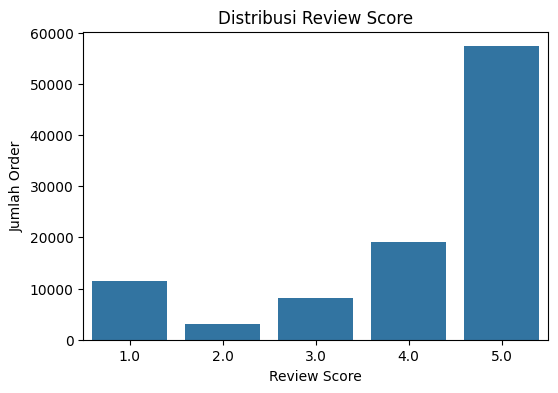

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=all_df, x="review_score")
plt.title("Distribusi Review Score")
plt.xlabel("Review Score")
plt.ylabel("Jumlah Order")
plt.show()

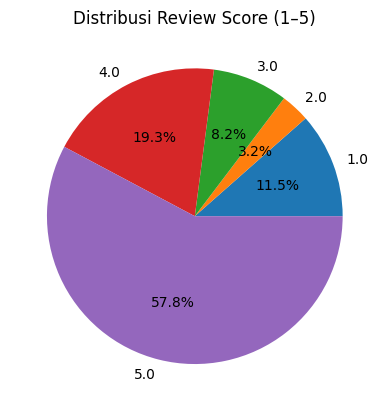

In [ ]:
review_counts = all_df['review_score'].value_counts().sort_index()
review_percent = review_counts / review_counts.sum() * 100

plt.figure()
plt.pie(review_percent, labels=review_percent.index, autopct='%1.1f%%')
plt.title('Distribusi Review Score (1–5)')
plt.show()

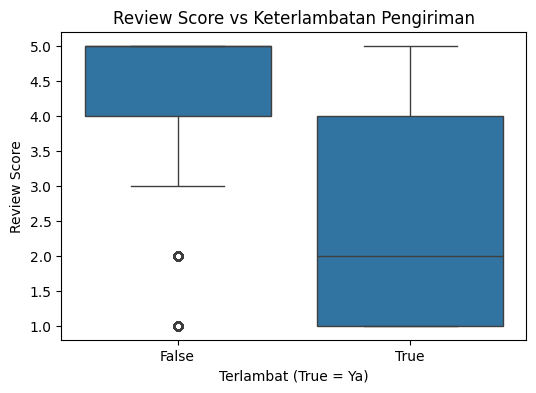

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=all_df, x="is_late", y="review_score")
plt.title("Review Score vs Keterlambatan Pengiriman")
plt.xlabel("Terlambat (True = Ya)")
plt.ylabel("Review Score")
plt.show()

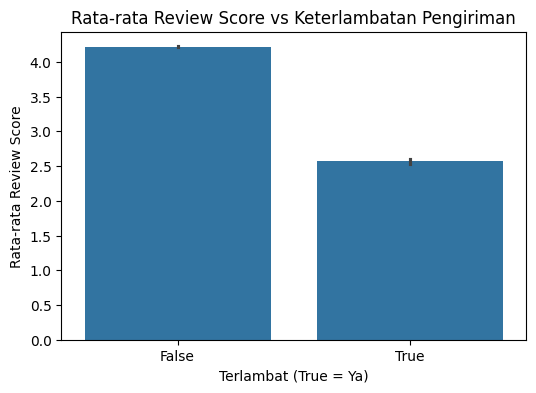

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(
    data=all_df,
    x="is_late",
    y="review_score",
    estimator="mean"
)

plt.title("Rata-rata Review Score vs Keterlambatan Pengiriman")
plt.xlabel("Terlambat (True = Ya)")
plt.ylabel("Rata-rata Review Score")

plt.show()

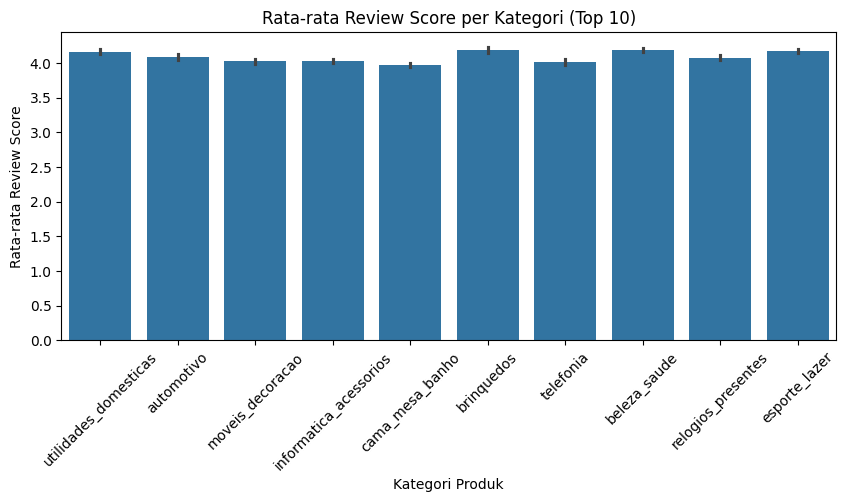

In [ ]:
top_category = (
    all_df["product_category_name"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10,4))
sns.barplot(
    data=all_df[all_df["product_category_name"].isin(top_category)],
    x="product_category_name",
    y="review_score"
)
plt.title("Rata-rata Review Score per Kategori (Top 10)")
plt.xlabel("Kategori Produk")
plt.ylabel("Rata-rata Review Score")
plt.xticks(rotation=45)
plt.show()

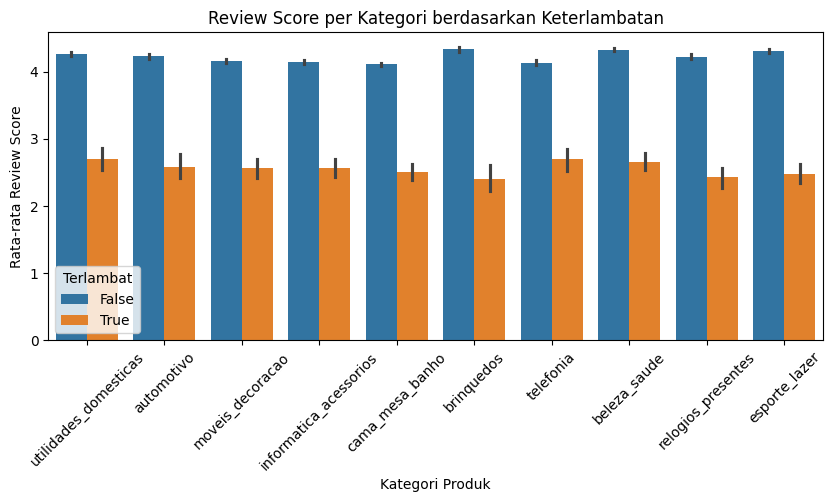

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=all_df[all_df["product_category_name"].isin(top_category)],
    x="product_category_name",
    y="review_score",
    hue="is_late"
)
plt.title("Review Score per Kategori berdasarkan Keterlambatan")
plt.xlabel("Kategori Produk")
plt.ylabel("Rata-rata Review Score")
plt.xticks(rotation=45)
plt.legend(title="Terlambat")
plt.show()

**Insight:**

Analisis visual dilakukan secara bertahap.
Distribusi review score dianalisis terlebih dahulu untuk memahami karakteristik data.
Selanjutnya, hubungan antara keterlambatan pengiriman dan review score dianalisis secara bivariate.
Analisis kemudian diperluas dengan memasukkan kategori produk untuk mengidentifikasi variasi kepuasan pelanggan antar kategori serta konsistensi dampak keterlambatan pengiriman.

### Pertanyaan 2:Bagaimana perkembangan revenue bulanan selama periode 2016–2018?

In [ ]:
monthly_revenue = (
    all_df
    .assign(order_month=all_df["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("order_month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

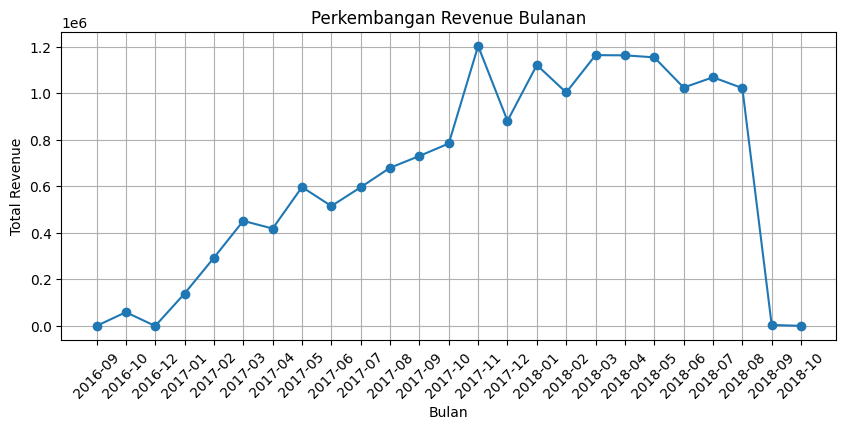

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["payment_value"],
    marker="o"
)
plt.title("Perkembangan Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

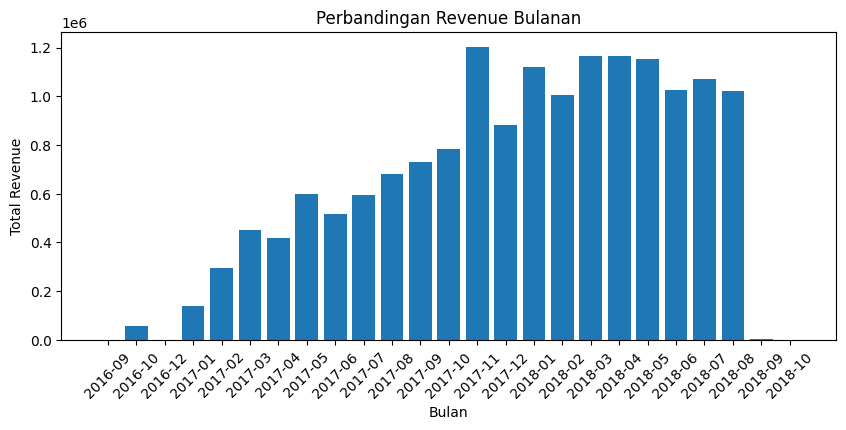

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(
    monthly_revenue["order_month"],
    monthly_revenue["payment_value"]
)
plt.title("Perbandingan Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Analisis revenue dilakukan menggunakan agregasi bulanan untuk menangkap tren pendapatan dari waktu ke waktu.
Hasil visualisasi menunjukkan bahwa revenue mengalami fluktuasi antar bulan, dengan beberapa periode menunjukkan peningkatan signifikan.
Pola ini mengindikasikan adanya kemungkinan seasonality atau pengaruh momen tertentu seperti promosi dan periode belanja besar.

### Pertanyaan 3: Bagaimana Segmentasi customer berdasarkan nilai belanja

In [ ]:
customer_spending = (
    all_df
    .groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "total_spending"})
)

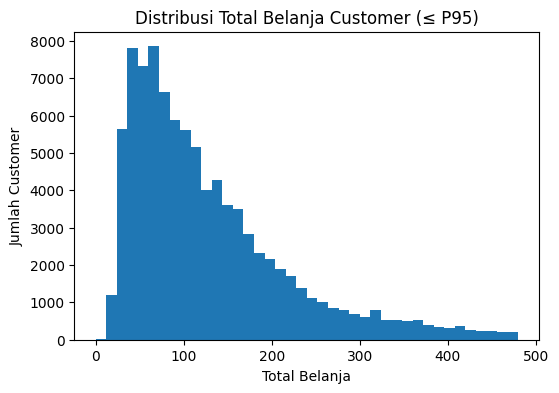

In [ ]:
upper_limit = customer_spending["total_spending"].quantile(0.95)

plt.figure(figsize=(6,4))
plt.hist(
    customer_spending.loc[
        customer_spending["total_spending"] <= upper_limit,
        "total_spending"
    ],
    bins=40
)
plt.title("Distribusi Total Belanja Customer (≤ P95)")
plt.xlabel("Total Belanja")
plt.ylabel("Jumlah Customer")
plt.show()

In [ ]:
q60 = customer_spending["total_spending"].quantile(0.6)
q90 = customer_spending["total_spending"].quantile(0.9)

def segment_customer(x):
    if x <= q60:
        return "Low Value"
    elif x <= q90:
        return "Mid Value"
    else:
        return "High Value"

customer_spending["segment"] = customer_spending["total_spending"].apply(segment_customer)

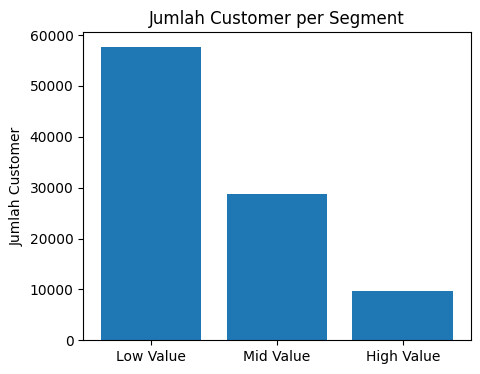

In [ ]:
segment_count = customer_spending["segment"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(segment_count.index, segment_count.values)
plt.title("Jumlah Customer per Segment")
plt.ylabel("Jumlah Customer")
plt.show()

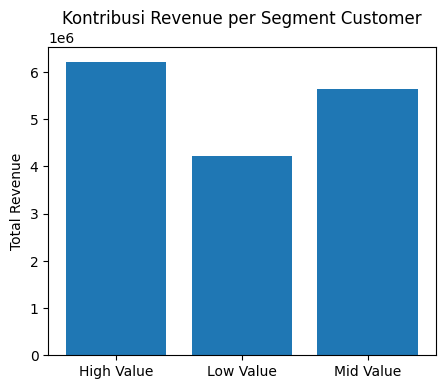

In [ ]:
segment_revenue = (
    customer_spending
    .groupby("segment")["total_spending"]
    .sum()
)

plt.figure(figsize=(5,4))
plt.bar(segment_revenue.index, segment_revenue.values)
plt.title("Kontribusi Revenue per Segment Customer")
plt.ylabel("Total Revenue")
plt.show()

**Insight Utama:**
- Distribusi total belanja customer bersifat right-skewed, di mana mayoritas customer memiliki nilai belanja rendah, sementara sebagian kecil customer memiliki belanja sangat tinggi.
- Terdapat ketimpangan kontribusi revenue, di mana segmen kecil customer menyumbang porsi pendapatan yang signifikan.
- Segmentasi customer menjadi Low Value, Mid Value, dan High Value Customer menunjukkan bahwa:
  - Low Value Customer mendominasi jumlah pelanggan namun kontribusi revenue relatif kecil.
  - High Value Customer jumlahnya terbatas tetapi berkontribusi besar terhadap total revenue.

### Pertanyaan 4: Seberapa besar perbedaan rata-rata nilai transaksi dan frekuensi pembelian berdasarkan metode pembayaran yang digunakan?

In [ ]:
payment_summary = all_df.groupby("payment_type").agg(
    avg_transaction_value=("payment_value", "mean"),
    total_orders=("order_id", "nunique"),
    total_transactions=("payment_value", "count")
).reset_index()

# Urutkan berdasarkan rata-rata transaksi
payment_summary = payment_summary.sort_values(
    by="avg_transaction_value",
    ascending=False
)

print(payment_summary)

  payment_type  avg_transaction_value  total_orders  total_transactions
1  credit_card             166.446261         75387               75785
0       boleto             144.986413         19784               19910
2   debit_card             142.549628          1527                1534
4      voucher             131.185299          2739                2759
3  not_defined               0.000000             3                   3


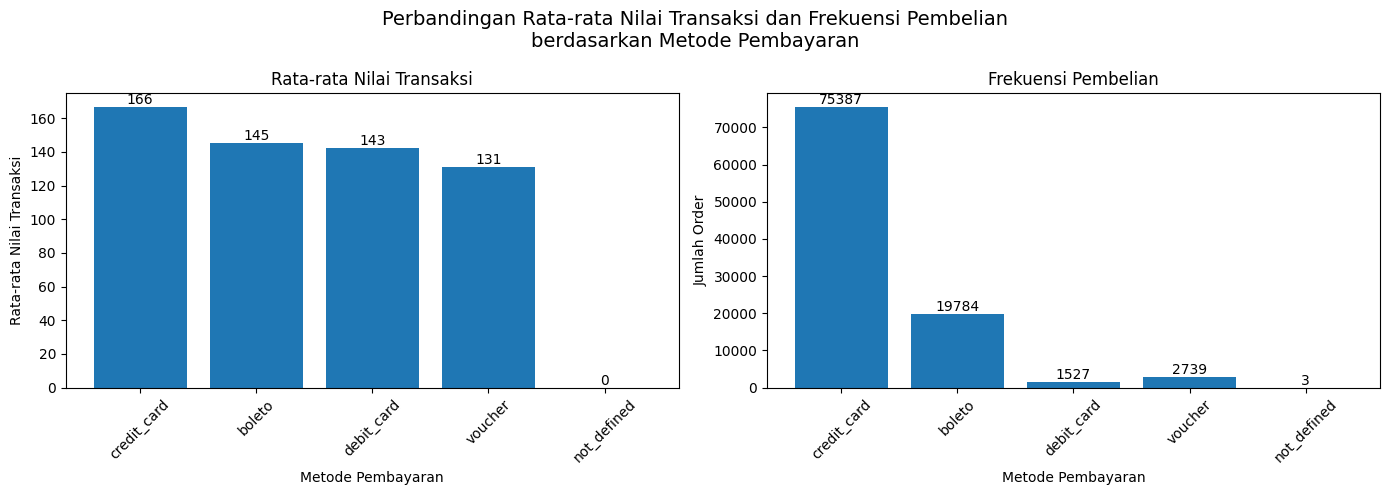

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Chart 1: Average Transaction Value ---
axes[0].bar(
    payment_summary["payment_type"],
    payment_summary["avg_transaction_value"]
)

axes[0].set_title("Rata-rata Nilai Transaksi")
axes[0].set_xlabel("Metode Pembayaran")
axes[0].set_ylabel("Rata-rata Nilai Transaksi")
axes[0].tick_params(axis='x', rotation=45)

# Tambahkan label angka
for i, v in enumerate(payment_summary["avg_transaction_value"]):
    axes[0].text(i, v, f"{v:.0f}", ha='center', va='bottom')

# --- Chart 2: Total Orders (Frequency) ---
axes[1].bar(
    payment_summary["payment_type"],
    payment_summary["total_orders"]
)

axes[1].set_title("Frekuensi Pembelian")
axes[1].set_xlabel("Metode Pembayaran")
axes[1].set_ylabel("Jumlah Order")
axes[1].tick_params(axis='x', rotation=45)

# Tambahkan label angka
for i, v in enumerate(payment_summary["total_orders"]):
    axes[1].text(i, v, f"{v}", ha='center', va='bottom')

plt.suptitle(
    "Perbandingan Rata-rata Nilai Transaksi dan Frekuensi Pembelian\nberdasarkan Metode Pembayaran",
    fontsize=14
)

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

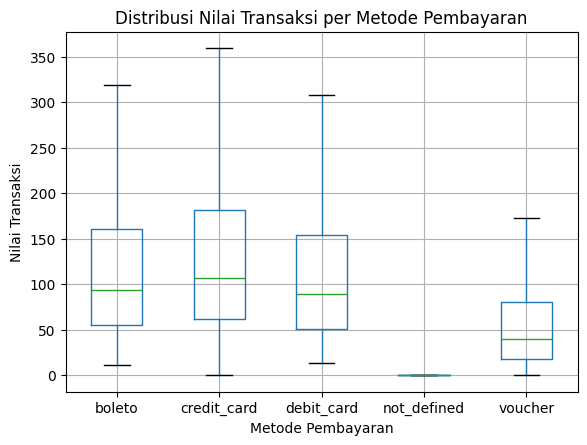

In [ ]:
plt.figure(figsize=(6,4))
order_payments_df.boxplot(
    column="payment_value",
    by="payment_type",
    showfliers=False
)
plt.title("Distribusi Nilai Transaksi per Metode Pembayaran")
plt.suptitle("")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Nilai Transaksi")
plt.show()

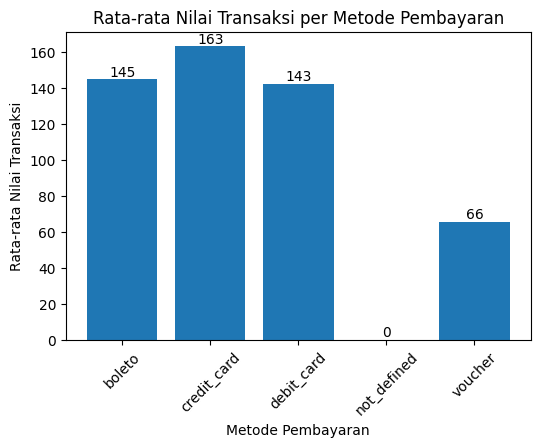

In [ ]:
avg_payment = order_payments_df.groupby("payment_type")["payment_value"].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_payment.index, avg_payment.values)

plt.title("Rata-rata Nilai Transaksi per Metode Pembayaran")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Rata-rata Nilai Transaksi")
plt.xticks(rotation=45)

# Tambahkan label angka di atas bar
for i, v in enumerate(avg_payment.values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.show()

**Insight**

- Credit card dan boleto mendominasi frekuensi pembelian, dengan credit card tertinggi (76.505 order) dan boleto (19.784 order).  
- Rata-rata nilai transaksi tertinggi terjadi pada credit card (≈180) dan boleto (≈177), menunjukkan kedua metode ini digunakan untuk pembelian bernilai lebih tinggi.  
- Debit card dan voucher memiliki frekuensi dan nilai transaksi lebih rendah, dengan voucher terutama digunakan untuk transaksi berjumlah kecil (rata-rata ≈67).  
- Metode “not_defined” hampir tidak digunakan (0–3 transaksi), tidak signifikan dalam analisis perilaku pembayaran.  
- Secara keseluruhan, credit card menjadi metode pembayaran utama yang memberikan volume dan nilai transaksi tertinggi.

### Pertanyaan 5:  Seberapa besar perbedaan tingkat kepuasan pelanggan dan repeat order antara pengiriman tepat waktu dan terlambat?

In [ ]:
delivery_df = orders_df.copy()

delivery_df["is_late"] = (
    delivery_df["order_delivered_customer_date"]
    > delivery_df["order_estimated_delivery_date"]
)

In [ ]:
delivery_review_df = (
    delivery_df
    .merge(
        order_reviews_df[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

In [ ]:
delivery_review_df.groupby("is_late").agg(
    avg_review=("review_score", "mean"),
    median_review=("review_score", "median"),
    total_orders=("order_id", "count")
)

,avg_review,median_review,total_orders
is_late,,,
False,4.214307,5.0,91523
True,2.566550,2.0,7701


<Figure size 400x400 with 0 Axes>

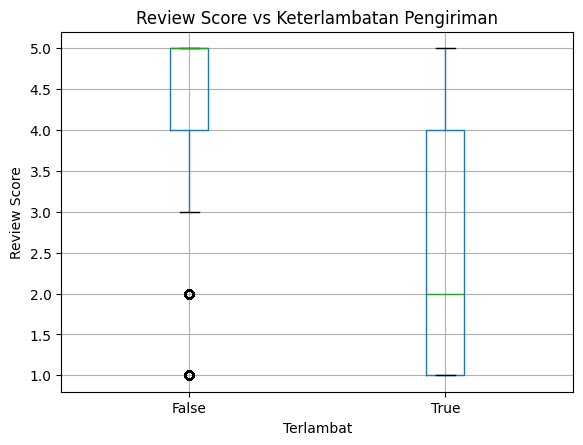

In [ ]:
plt.figure(figsize=(4,4))
delivery_review_df.boxplot(
    column="review_score",
    by="is_late"
)
plt.title("Review Score vs Keterlambatan Pengiriman")
plt.suptitle("")
plt.xlabel("Terlambat")
plt.ylabel("Review Score")
plt.show()

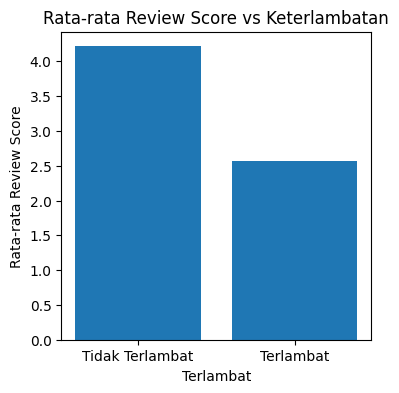

In [ ]:
# Hitung rata-rata review score berdasarkan keterlambatan
avg_review = delivery_review_df.groupby("is_late")["review_score"].mean()

plt.figure(figsize=(4,4))
plt.bar(avg_review.index, avg_review.values)

plt.title("Rata-rata Review Score vs Keterlambatan")
plt.xlabel("Terlambat")
plt.ylabel("Rata-rata Review Score")
plt.xticks([0,1], ["Tidak Terlambat", "Terlambat"])

plt.show()

In [ ]:
late_ratio_df = (
    delivery_df
    .merge(customers_df, on="customer_id")
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

late_ratio_df["late_ratio"] = (
    late_ratio_df["late_orders"] / late_ratio_df["total_orders"]
)

In [ ]:
late_ratio_df.groupby(
    pd.cut(late_ratio_df["late_ratio"], [0, 0.25, 0.5, 0.75, 1])
).agg(
    avg_orders=("total_orders", "mean"),
    customer_count=("customer_unique_id", "count")
)

/tmp/ipython-input-158/2351126279.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  late_ratio_df.groupby(


,avg_orders,customer_count
late_ratio,,
"(0.0, 0.25]",5.454545,11
"(0.25, 0.5]",2.080386,311
"(0.5, 0.75]",3.000000,6
"(0.75, 1.0]",1.006448,7444


In [ ]:
all_df['delivery_status'] = all_df.apply(
    lambda x: 'On Time' if x['order_delivered_customer_date'] <= x['order_estimated_delivery_date'] else 'Late',
    axis=1
)

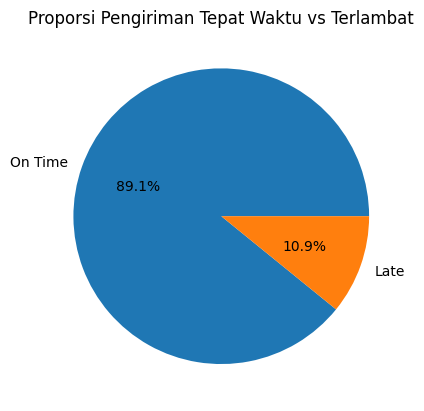

In [ ]:
delivery_counts = all_df['delivery_status'].value_counts()
delivery_percent = delivery_counts / delivery_counts.sum() * 100

plt.figure()
plt.pie(delivery_percent, labels=delivery_percent.index, autopct='%1.1f%%')
plt.title('Proporsi Pengiriman Tepat Waktu vs Terlambat')
plt.show()

**Insight**

Performa pengiriman memiliki pengaruh signifikan terhadap kepuasan pelanggan
dan perilaku repeat order. Order yang dikirim terlambat cenderung menerima
review score yang lebih rendah dibandingkan order yang dikirim tepat waktu.
Selain itu, customer dengan proporsi keterlambatan pengiriman yang lebih tinggi
menunjukkan rata-rata jumlah order yang lebih rendah. Hal ini mengindikasikan
bahwa pengalaman pengiriman yang buruk tidak hanya berdampak pada kepuasan
sesaat, tetapi juga menurunkan kecenderungan pelanggan untuk melakukan
pembelian ulang.

## Analisis Lanjutan (Opsional)

In [ ]:
snapshot_date = all_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

In [ ]:
rfm_base = (
    all_df
    .groupby("customer_unique_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x: (snapshot_date - x.max()).days
        ),
        Frequency=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
monetary = (
    all_df
    .groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "Monetary"})
)

rfm = rfm_base.merge(
    monetary,
    on="customer_unique_id",
    how="left"
)

In [ ]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [ ]:
def rfm_segment(row):
    if row["R_score"] == 4 and row["F_score"] == 4 and row["M_score"] == 4:
        return "Best Customer"
    elif row["F_score"] == 4 and row["M_score"] >= 3:
        return "Loyal Customer"
    elif row["R_score"] >= 3 and row["F_score"] <= 2:
        return "Potential Customer"
    elif row["R_score"] == 1 and row["F_score"] >= 3:
        return "At Risk Customer"
    else:
        return "Low Value Customer"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Low Value Customer,50449
Potential Customer,23967
Loyal Customer,10980
At Risk Customer,8847
Best Customer,1853


In [ ]:
rfm.groupby("Segment")["Monetary"].agg(
    total_revenue="sum",
    avg_revenue="mean",
    customer_count="count"
).sort_values("total_revenue", ascending=False)

,total_revenue,avg_revenue,customer_count
Segment,,,
Low Value Customer,7354419.07,145.779283,50449
Potential Customer,3875644.31,161.707527,23967
Loyal Customer,2903768.06,264.459750,10980
At Risk Customer,1164139.50,131.585792,8847
Best Customer,783449.80,422.800756,1853


In [ ]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        customer_count=("customer_unique_id", "count"),
        total_revenue=("Monetary", "sum"),
        avg_revenue=("Monetary", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)


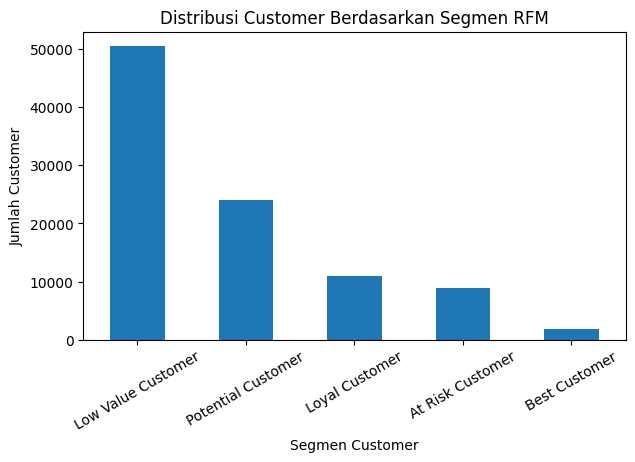

In [ ]:
segment_count = rfm["Segment"].value_counts()

plt.figure(figsize=(7,4))
segment_count.plot(kind="bar")
plt.title("Distribusi Customer Berdasarkan Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Jumlah Customer")
plt.xticks(rotation=30)
plt.show()

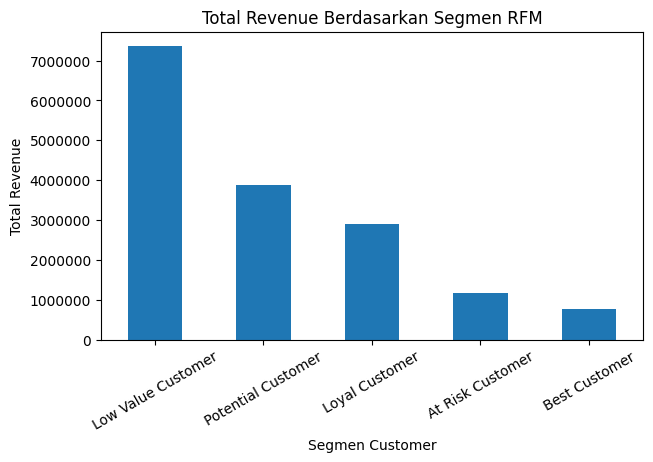

In [ ]:
segment_revenue = (
    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))
segment_revenue.plot(kind="bar")
plt.title("Total Revenue Berdasarkan Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.ticklabel_format(style='plain', axis='y')
plt.show()


In [ ]:
order_count = (
    all_df
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

rfm_repeat = rfm.merge(
    order_count,
    on="customer_unique_id",
    how="left"
)

rfm_repeat.groupby("Segment")["total_orders"].mean().sort_values(ascending=False)

,total_orders
Segment,
Best Customer,1.375067
Loyal Customer,1.210565
At Risk Customer,1.009382
Low Value Customer,1.005055
Potential Customer,1.000000


In [ ]:
delivery_rate = (
    all_df
    .groupby("customer_unique_id")["is_late"]
    .mean()
    .reset_index()
)

rfm_delivery = rfm.merge(
    delivery_rate,
    on="customer_unique_id",
    how="left"
)

late_by_segment = (
    rfm_delivery
    .groupby("Segment")["is_late"]
    .mean()
    .sort_values(ascending=False)
)

print(late_by_segment)

Segment
Potential Customer    0.095131
Loyal Customer        0.084395
Low Value Customer    0.078337
Best Customer         0.058721
At Risk Customer      0.037866
Name: is_late, dtype: float64


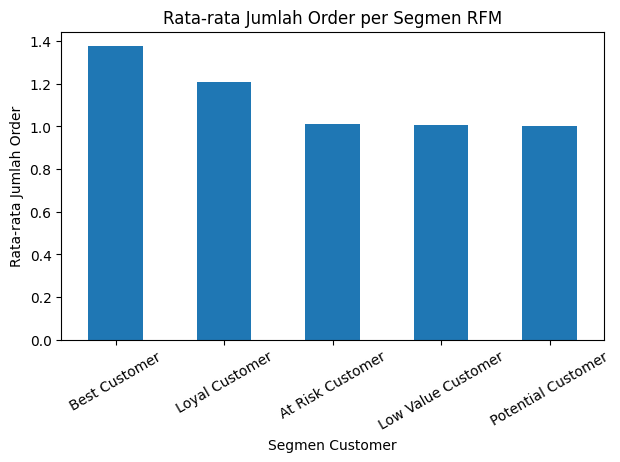

In [ ]:
repeat_by_segment = (
    rfm_repeat
    .groupby("Segment")["total_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))
repeat_by_segment.plot(kind="bar")
plt.title("Rata-rata Jumlah Order per Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Rata-rata Jumlah Order")
plt.xticks(rotation=30)
plt.show()

**Insight**

- Performa pengiriman dan metode pembayaran berpengaruh terhadap kepuasan, repeat order, dan nilai transaksi pelanggan.
- Analisis RFM menunjukkan bahwa sebagian kecil pelanggan menyumbang porsi revenue terbesar, sementara mayoritas pelanggan memiliki nilai belanja rendah.
- Oleh karena itu, peningkatan kualitas pengiriman serta strategi retensi pelanggan bernilai tinggi menjadi kunci untuk pertumbuhan bisnis yang berkelanjutan.

## Conclusion

#### 1. Distribusi Rating Pelanggan berdasarkan Waktu Pengiriman dan Kategori Produk
Mayoritas pelanggan sangat puas, dengan rata-rata review score 4,09 dan median 5. Rating 5 mendominasi 57,78%, sedangkan rating 1 hanya 11,51%, menunjukkan persepsi kualitas yang kuat secara umum.

Namun, terdapat korelasi jelas antara keterlambatan dan penurunan rating. Meski hanya 6,57% order terlambat (93,43% tepat waktu), order yang terlambat memiliki rata-rata skor lebih rendah, menegaskan bahwa performa logistik berdampak langsung pada kepuasan pelanggan.

Selain itu, terdapat variasi rating antar kategori produk. Produk berukuran besar dan berat, seperti furniture, cenderung memiliki risiko keterlambatan lebih tinggi sehingga lebih rentan menerima rating lebih rendah.


#### 2. Bagaimana perkembangan revenue bulanan selama periode 2016–2018?
Order tumbuh pesat dari 329 (2016) menjadi 45.101 (2017) dan 54.011 (2018), menunjukkan akselerasi bisnis yang sangat kuat. Puncak volume terjadi November 2017 (7.544 order), mengindikasikan lonjakan akhir tahun.

Pendapatan tertinggi tercatat Januari 2018 (1.115.004,18), mencerminkan dampak lanjutan momentum akhir tahun terhadap revenue. Penurunan ekstrem pada September (16 order) dan Oktober 2018 (4 order) kemungkinan besar akibat keterbatasan data, bukan kontraksi bisnis riil.

Secara keseluruhan, tren memperlihatkan growth konsisten 2016–2018 dengan indikasi seasonality kuat di periode akhir tahun.

#### 3. Segmentasi Customer berdasarkan Nilai Belanja
Tercatat 96.096 pelanggan dengan rata-rata order 1,03 dan median 1, menandakan perilaku transaksi sangat didominasi pembelian tunggal. Sebanyak 96,88% adalah single buyer, sementara repeat buyer hanya 3,12%, menunjukkan retensi masih rendah.

Rata-rata total belanja per pelanggan 166,59 (median 108,00), dengan nilai maksimum 13.664,08. Distribusi yang right-skewed ini menunjukkan ketimpangan kontribusi revenue, di mana sebagian kecil pelanggan menyumbang porsi pendapatan yang sangat besar.


#### 4. Seberapa besar perbedaan rata-rata nilai transaksi dan frekuensi pembelian berdasarkan metode pembayaran yang digunakan?
Credit_card mendominasi dengan 76.795 transaksi dan total revenue 12.542.084,19, serta rata-rata nilai transaksi tertinggi (~163), menunjukkan preferensi pelanggan untuk pembayaran bernilai lebih besar. Sebaliknya, voucher memiliki rata-rata nilai transaksi terendah (65-67).

Dari sisi kepuasan, debit_card mencatat review score tertinggi (4,17), sementara voucher terendah (4,00). Ini mengindikasikan adanya keterkaitan antara metode pembayaran, nilai transaksi, dan tingkat kepuasan pelanggan.

#### 5. Seberapa besar perbedaan tingkat kepuasan pelanggan dan repeat order antara pengiriman tepat waktu dan terlambat?
Order terlambat tidak hanya menurunkan rating, tetapi juga berkorelasi dengan frekuensi repeat order yang lebih rendah

Durasi pengiriman memiliki variasi ekstrem (minimum −147 hari, maksimum 188 hari) yang mengindikasikan anomali data. Meski mayoritas pengiriman berada pada rentang normal

In [ ]:
all_df.to_csv("all_df.csv", index=False)